# Málaga bajo presión

## ¿Cómo afecta la presión turística a los residentes de Málaga?

### Problema

Málaga ha experimentado un importante crecimiento turístico en los últimos años. 
Aunque el turismo genera actividad económica y empleo, su concentración puede 
generar presión sobre determinadas zonas de la ciudad y afectar a la percepción 
de sus residentes.

El objetivo de este proyecto es analizar cómo se distribuye la presión turística 
en Málaga e investigar qué factores pueden estar relacionados con una percepción 
más negativa del turismo por parte de los residentes.

### Pregunta principal

¿Qué factores están asociados con una mayor percepción negativa del turismo entre 
los residentes de Málaga y dónde se concentra esa presión?

### Hipótesis

- **H1:** La percepción del turismo no es homogénea en Málaga y existen diferencias entre distritos.
- **H2:** Las zonas con mayor presión turística presentan una percepción más negativa del turismo.
- **H3:** La concentración de viviendas turísticas puede estar relacionada con una mayor percepción negativa del turismo.

# Análisis de la presión turística y la percepción de los residentes en Málaga

## 1. Introducción y objetivo

El objetivo de este proyecto es analizar la relación entre la concentración de viviendas de uso turístico (VUT) y la percepción del turismo por parte de los residentes de Málaga.

El análisis se realiza a nivel de los 11 distritos municipales de Málaga, tomando 2023 como año de referencia para los datos de percepción.

### 1.1 Pregunta de investigación

¿Existe relación entre la concentración de viviendas de uso turístico y la percepción negativa del turismo en los distintos distritos de Málaga?

In [135]:
# Importación de librerías 
import pandas as pd
import requests
import re
import pdfplumber
import geopandas as gpd

from cleaning import clean_percentage_columns, clean_vut_data, clean_vut_types

In [134]:
import importlib
import cleaning

importlib.reload(cleaning)

from cleaning import clean_percentage_columns, clean_vut_data, clean_vut_types

### Fuente 1: Actividad turística

La primera fuente utilizada será el Instituto Nacional de Estadística (INE).

Se utilizarán datos relacionados con la actividad turística en Málaga, como el número de viajeros y pernoctaciones, con el objetivo de estudiar la evolución de la presión turística en la ciudad.

In [105]:
url_ine = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/75197"

response_ine = requests.get(url_ine)

response_ine.status_code

200

In [106]:
data_ine = response_ine.json()

len(data_ine)

552

In [107]:
malaga_series = []

for serie in data_ine:
    if "Málaga" in serie["Nombre"]:
        malaga_series.append(serie)

len(malaga_series)

4

In [8]:
for serie in malaga_series:
    print(serie["Nombre"])

Nacional. Viajeros. Málaga. Residentes en España.
Nacional. Viajeros. Málaga. Residentes en el extranjero.
Nacional. Pernoctaciones. Málaga. Residentes en España.
Nacional. Pernoctaciones. Málaga. Residentes en el extranjero.


In [9]:
rows = []

for serie in malaga_series:
    
    if "Viajeros" in serie["Nombre"]:
        indicador = "viajeros"
    else:
        indicador = "pernoctaciones"
    
    if "Residentes en España" in serie["Nombre"]:
        residencia = "España"
    else:
        residencia = "Extranjero"
    
    for registro in serie["Data"]:
        rows.append({
            "year": registro["Anyo"],
            "month": registro["FK_Periodo"],
            "indicator": indicador,
            "residence": residencia,
            "value": registro["Valor"]
        })

In [10]:
tourism_df = pd.DataFrame(rows)

tourism_df.head()

,year,month,indicator,residence,value
0,2026,8,viajeros,España,49634.0
1,2026,7,viajeros,España,47092.0
2,2026,6,viajeros,España,42812.0
3,2026,5,viajeros,España,39661.0
4,2026,4,viajeros,España,44026.0


In [11]:
tourism_df.shape

(80, 5)

In [12]:
tourism_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       80 non-null     int64  
 1   month      80 non-null     int64  
 2   indicator  80 non-null     str    
 3   residence  80 non-null     str    
 4   value      80 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.8 KB


In [13]:
# Comprobamos los años disponibles en el dataset
sorted(tourism_df["year"].unique())

[np.int64(2025), np.int64(2026)]

In [14]:
# Comprobamos cuántos registros tenemos por año
tourism_df["year"].value_counts().sort_index()

year
2025    48
2026    32
Name: count, dtype: int64

In [15]:
# Comprobamos las categorías de cada variable
print(tourism_df["indicator"].unique())
print(tourism_df["residence"].unique())

<ArrowStringArray>
['viajeros', 'pernoctaciones']
Length: 2, dtype: str
<ArrowStringArray>
['España', 'Extranjero']
Length: 2, dtype: str


In [108]:
# Comprobamos valores nulos y filas duplicadas
print("Valores nulos:")
print(tourism_df.isnull().sum())

print("\nFilas duplicadas:", tourism_df.duplicated().sum())

Valores nulos:
year         0
month        0
indicator    0
residence    0
value        0
date         0
dtype: int64

Filas duplicadas: 0


Los datos obtenidos del INE no presentan valores nulos ni filas duplicadas y las variables tienen tipos adecuados para el análisis.

El dataset contiene información de 2025 y 2026.

In [16]:
# Comprobamos cuántos registros contiene cada serie original
for serie in malaga_series:
    print(serie["Nombre"])
    print("Número de registros:", len(serie["Data"]))
    print("Año más antiguo:", min(registro["Anyo"] for registro in serie["Data"]))
    print("Año más reciente:", max(registro["Anyo"] for registro in serie["Data"]))
    print()

Nacional. Viajeros. Málaga. Residentes en España.
Número de registros: 20
Año más antiguo: 2025
Año más reciente: 2026

Nacional. Viajeros. Málaga. Residentes en el extranjero.
Número de registros: 20
Año más antiguo: 2025
Año más reciente: 2026

Nacional. Pernoctaciones. Málaga. Residentes en España.
Número de registros: 20
Año más antiguo: 2025
Año más reciente: 2026

Nacional. Pernoctaciones. Málaga. Residentes en el extranjero.
Número de registros: 20
Año más antiguo: 2025
Año más reciente: 2026



In [22]:
# Observamos estadísticas básicas de la variable numérica
tourism_df["value"].describe()

count        80.000000
mean     115540.187500
std       69033.010529
min       39661.000000
25%       62021.500000
50%       94716.500000
75%      130866.000000
max      313458.000000
Name: value, dtype: float64

In [23]:
# Creamos una columna de fecha combinando el año y el mes
tourism_df["date"] = pd.to_datetime(
    tourism_df["year"].astype(str) + "-" +
    tourism_df["month"].astype(str) + "-01"
)

tourism_df.head()

,year,month,indicator,residence,value,date
0,2026,8,viajeros,España,49634.0,2026-08-01
1,2026,7,viajeros,España,47092.0,2026-07-01
2,2026,6,viajeros,España,42812.0,2026-06-01
3,2026,5,viajeros,España,39661.0,2026-05-01
4,2026,4,viajeros,España,44026.0,2026-04-01


In [24]:
tourism_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   year       80 non-null     int64         
 1   month      80 non-null     int64         
 2   indicator  80 non-null     str           
 3   residence  80 non-null     str           
 4   value      80 non-null     float64       
 5   date       80 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 5.4 KB


In [ ]:
# INE año 2023
url_ine_2023 = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/69868"

response_ine_2023 = requests.get(url_ine_2023)

response_ine_2023.status_code

200

In [166]:
data_ine_2023[0]["Data"][:3]

[{'Valor': 348346.0, 'Secreto': False}]

In [167]:
data_ine_2023[0]["Nombre"]

'01059 VITORIA-GASTEIZ, Total, Total'

In [168]:
[
    serie["Nombre"]
    for serie in data_ine_2023
    if "MÁLAGA" in serie["Nombre"].upper()
][:10]

['29067 MÁLAGA, Total, Total',
 '29067 MÁLAGA, Total, Enero',
 '29067 MÁLAGA, Total, Febrero',
 '29067 MÁLAGA, Total, Marzo',
 '29067 MÁLAGA, Total, Abril',
 '29067 MÁLAGA, Total, Mayo',
 '29067 MÁLAGA, Total, Junio',
 '29067 MÁLAGA, Total, Julio',
 '29067 MÁLAGA, Total, Agosto',
 '29067 MÁLAGA, Total, Septiembre']

In [169]:
[
    serie["Nombre"]
    for serie in data_ine_2023
    if "29067 MÁLAGA" in serie["Nombre"]
    and serie["Nombre"].endswith(", Enero")
]

['29067 MÁLAGA, Total, Enero',
 '29067 MÁLAGA, Residentes en España, Enero',
 '29067 MÁLAGA, No residentes en España, Enero',
 '29067 MÁLAGA, Unión Europea 27 (sin España), Enero',
 '29067 MÁLAGA, Alemania, Enero',
 '29067 MÁLAGA, Bélgica, Enero',
 '29067 MÁLAGA, Francia, Enero',
 '29067 MÁLAGA, Italia, Enero',
 '29067 MÁLAGA, Países Bajos, Enero',
 '29067 MÁLAGA, Portugal, Enero',
 '29067 MÁLAGA, Reino Unido, Enero',
 '29067 MÁLAGA, Japón, Enero',
 '29067 MÁLAGA, República China, Enero',
 '29067 MÁLAGA, Estados Unidos, Enero']

In [171]:
malaga_travelers_2023 = [
    serie
    for serie in data_ine_2023
    if "29067 MÁLAGA" in serie["Nombre"]
    and (
        "Residentes en España" in serie["Nombre"]
        or "No residentes en España" in serie["Nombre"]
    )
    and not serie["Nombre"].endswith(", Total")
]

len(malaga_travelers_2023)

24

In [172]:
malaga_travelers_2023[0]

{'Nombre': '29067 MÁLAGA, Residentes en España, Enero',
 'Data': [{'Valor': 43944.0, 'Secreto': False}]}

In [173]:
traveler_rows = []

for serie in malaga_travelers_2023:
    location, residence, month = serie["Nombre"].split(", ")
    value = serie["Data"][0]["Valor"]

    traveler_rows.append({
        "year": 2023,
        "month": month,
        "residence": residence,
        "value": value
    })

traveler_rows[:3]

[{'year': 2023,
  'month': 'Enero',
  'residence': 'Residentes en España',
  'value': 43944.0},
 {'year': 2023,
  'month': 'Febrero',
  'residence': 'Residentes en España',
  'value': 46985.0},
 {'year': 2023,
  'month': 'Marzo',
  'residence': 'Residentes en España',
  'value': 63631.0}]

In [174]:
travelers_df = pd.DataFrame(traveler_rows)

travelers_df

,year,month,residence,value
0,2023,Enero,Residentes en España,43944.0
1,2023,Febrero,Residentes en España,46985.0
2,2023,Marzo,Residentes en España,63631.0
3,2023,Abril,Residentes en España,51998.0
4,2023,Mayo,Residentes en España,52852.0
5,2023,Junio,Residentes en España,63820.0
6,2023,Julio,Residentes en España,57618.0
7,2023,Agosto,Residentes en España,51650.0
8,2023,Septiembre,Residentes en España,45316.0
9,2023,Octubre,Residentes en España,47862.0


In [176]:
url_overnights_2023 = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/69944"

response_overnights_2023 = requests.get(url_overnights_2023)

response_overnights_2023.status_code

200

In [177]:
data_overnights_2023 = response_overnights_2023.json()

[
    serie["Nombre"]
    for serie in data_overnights_2023
    if "29067 MÁLAGA" in serie["Nombre"]
][:10]

['29067 MÁLAGA, Total, Total',
 '29067 MÁLAGA, Total, Enero',
 '29067 MÁLAGA, Total, Febrero',
 '29067 MÁLAGA, Total, Marzo',
 '29067 MÁLAGA, Total, Abril',
 '29067 MÁLAGA, Total, Mayo',
 '29067 MÁLAGA, Total, Junio',
 '29067 MÁLAGA, Total, Julio',
 '29067 MÁLAGA, Total, Agosto',
 '29067 MÁLAGA, Total, Septiembre']

In [178]:
malaga_overnights_2023 = [
    serie
    for serie in data_overnights_2023
    if "29067 MÁLAGA" in serie["Nombre"]
    and (
        "Residentes en España" in serie["Nombre"]
        or "No residentes en España" in serie["Nombre"]
    )
    and not serie["Nombre"].endswith(", Total")
]

len(malaga_overnights_2023)

24

In [179]:
overnight_rows = []

for serie in malaga_overnights_2023:
    location, residence, month = serie["Nombre"].split(", ")
    value = serie["Data"][0]["Valor"]

    overnight_rows.append({
        "year": 2023,
        "month": month,
        "residence": residence,
        "value": value
    })

overnight_rows[:3]

[{'year': 2023,
  'month': 'Enero',
  'residence': 'Residentes en España',
  'value': 81126.0},
 {'year': 2023,
  'month': 'Febrero',
  'residence': 'Residentes en España',
  'value': 82768.0},
 {'year': 2023,
  'month': 'Marzo',
  'residence': 'Residentes en España',
  'value': 108507.0}]

In [180]:
overnights_df = pd.DataFrame(overnight_rows)

overnights_df

,year,month,residence,value
0,2023,Enero,Residentes en España,81126.0
1,2023,Febrero,Residentes en España,82768.0
2,2023,Marzo,Residentes en España,108507.0
3,2023,Abril,Residentes en España,99044.0
4,2023,Mayo,Residentes en España,97313.0
5,2023,Junio,Residentes en España,112889.0
6,2023,Julio,Residentes en España,109269.0
7,2023,Agosto,Residentes en España,118620.0
8,2023,Septiembre,Residentes en España,86799.0
9,2023,Octubre,Residentes en España,85293.0


In [181]:
travelers_df["indicator"] = "viajeros"
overnights_df["indicator"] = "pernoctaciones"

In [182]:
travelers_df.head()

,year,month,residence,value,indicator
0,2023,Enero,Residentes en España,43944.0,viajeros
1,2023,Febrero,Residentes en España,46985.0,viajeros
2,2023,Marzo,Residentes en España,63631.0,viajeros
3,2023,Abril,Residentes en España,51998.0,viajeros
4,2023,Mayo,Residentes en España,52852.0,viajeros


In [183]:
tourism_df = pd.concat(
    [travelers_df, overnights_df],
    ignore_index=True
)

tourism_df.shape

(48, 5)

In [184]:
tourism_df["residence"] = tourism_df["residence"].replace({
    "Residentes en España": "España",
    "No residentes en España": "Extranjero"
})

tourism_df["residence"].unique()

<ArrowStringArray>
['España', 'Extranjero']
Length: 2, dtype: str

In [185]:
tourism_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       48 non-null     int64  
 1   month      48 non-null     str    
 2   residence  48 non-null     str    
 3   value      48 non-null     float64
 4   indicator  48 non-null     str    
dtypes: float64(1), int64(1), str(3)
memory usage: 3.2 KB


In [186]:
print("Años:", tourism_df["year"].unique())
print("Indicadores:", tourism_df["indicator"].unique())
print("Residencias:", tourism_df["residence"].unique())

Años: [2023]
Indicadores: <ArrowStringArray>
['viajeros', 'pernoctaciones']
Length: 2, dtype: str
Residencias: <ArrowStringArray>
['España', 'Extranjero']
Length: 2, dtype: str


### Fuente 2: Percepción de los residentes
La segunda fuente utilizada es el Observatorio de Turismo Sostenible de Málaga (STO Málaga).

Se utilizarán datos de la Encuesta Ómnibus del Ayuntamiento de Málaga sobre la percepción del turismo entre los residentes de los distintos distritos de la ciudad.

El objetivo es analizar si existen diferencias territoriales en la percepción del turismo y estudiar posteriormente su posible relación con distintos indicadores de presión turística.

In [25]:
pdf_url = "https://sto.malaga.eu/export/sites/sto-malaga/indicadores/.galleries/Documentos-indicadores/satisfaccion-es.pdf"

response_pdf = requests.get(pdf_url)

response_pdf.status_code

200

In [26]:
with open("satisfaccion_turismo_malaga.pdf", "wb") as file:
    file.write(response_pdf.content)

print("PDF guardado correctamente")

PDF guardado correctamente


### Extracción de la tabla del PDF

A partir del informe descargado,extraigo mediante Python la tabla correspondiente a la percepción del turismo por distritos en 2023

In [109]:
# Extraemos el texto de la página donde se encuentra la tabla

with pdfplumber.open("satisfaccion_turismo_malaga.pdf") as pdf:
    page_text = pdf.pages[6].extract_text()

district_lines

['D1 73,88 18,26 7,86',
 'D3 73,16 9,9 16,94',
 'D4 69,88 12,5 17,62',
 'D5 87,8 7,13 5,07',
 'D6 82,35 14,06 3,59',
 'D7 78,1 16,05 5,85',
 'D8 60,53 39,47 0',
 'D9 82,62 0 17,38',
 'D11 73,94 7,37 18,69']

In [33]:
import re

# Buscamos todas las filas de distritos dentro del texto de la página
pattern = r"\bD(1[01]|[1-9])\s+(\d+,\d+|\d+)\s+(\d+,\d+|\d+)\s+(\d+,\d+|\d+)"

matches = re.findall(pattern, page_text)

matches

[('1', '73,88', '18,26', '7,86'),
 ('2', '78,91', '11,87', '9,22'),
 ('3', '73,16', '9,9', '16,94'),
 ('4', '69,88', '12,5', '17,62'),
 ('5', '87,8', '7,13', '5,07'),
 ('6', '82,35', '14,06', '3,59'),
 ('7', '78,1', '16,05', '5,85'),
 ('8', '60,53', '39,47', '0'),
 ('9', '82,62', '0', '17,38'),
 ('10', '75,91', '0', '24,09'),
 ('11', '73,94', '7,37', '18,69')]

In [119]:
perception_df = pd.DataFrame(
    matches,
    columns=["district", "positive_pct", "negative_pct", "no_answer_pct"]
)

perception_df.head()

,district,positive_pct,negative_pct,no_answer_pct
0,1,"73,88","18,26","7,86"
1,2,"78,91","11,87","9,22"
2,3,"73,16","9,9","16,94"
3,4,"69,88","12,5","17,62"
4,5,"87,8","7,13","5,07"


In [35]:
perception_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   district       11 non-null     str  
 1   positive_pct   11 non-null     str  
 2   negative_pct   11 non-null     str  
 3   no_answer_pct  11 non-null     str  
dtypes: str(4)
memory usage: 638.0 bytes


### Limpieza y preparación de los datos

Los porcentajes extraídos del PDF se encuentran inicialmente en formato texto y utilizan coma como separador decimal. Para poder analizarlos numéricamente, utilizo una función definida en `cleaning.py`.

In [120]:
# Convertimos las columnas de porcentajes de texto a valores numéricos

percentage_columns = ["positive_pct", "negative_pct", "no_answer_pct"]

perception_df = clean_percentage_columns(
    perception_df,
    percentage_columns
)

perception_df.head()

,district,positive_pct,negative_pct,no_answer_pct
0,1,73.88,18.26,7.86
1,2,78.91,11.87,9.22
2,3,73.16,9.90,16.94
3,4,69.88,12.50,17.62
4,5,87.80,7.13,5.07


In [122]:
# Convertimos el número de distrito a entero
perception_df["district"] = perception_df["district"].astype(int)

In [39]:
perception_df["negative_pct"].mean()

np.float64(12.41909090909091)

In [123]:
perception_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   district       11 non-null     int64  
 1   positive_pct   11 non-null     float64
 2   negative_pct   11 non-null     float64
 3   no_answer_pct  11 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 484.0 bytes


In [40]:
perception_df.sort_values("negative_pct", ascending=False)

,district,positive_pct,negative_pct,no_answer_pct
7,8,60.53,39.47,0.00
0,1,73.88,18.26,7.86
6,7,78.10,16.05,5.85
5,6,82.35,14.06,3.59
3,4,69.88,12.50,17.62
1,2,78.91,11.87,9.22
2,3,73.16,9.90,16.94
10,11,73.94,7.37,18.69
4,5,87.80,7.13,5.07
8,9,82.62,0.00,17.38


In [41]:
perception_df.isnull().sum()

district         0
positive_pct     0
negative_pct     0
no_answer_pct    0
dtype: int64

In [42]:
perception_df.duplicated().sum()

np.int64(0)

In [43]:
# Comprobamos que los porcentajes de cada distrito suman 100 %

perception_df["total_pct"] = (
    perception_df["positive_pct"] +
    perception_df["negative_pct"] +
    perception_df["no_answer_pct"]
)

perception_df

,district,positive_pct,negative_pct,no_answer_pct,total_pct
0,1,73.88,18.26,7.86,100.0
1,2,78.91,11.87,9.22,100.0
2,3,73.16,9.90,16.94,100.0
3,4,69.88,12.50,17.62,100.0
4,5,87.80,7.13,5.07,100.0
5,6,82.35,14.06,3.59,100.0
6,7,78.10,16.05,5.85,100.0
7,8,60.53,39.47,0.00,100.0
8,9,82.62,0.00,17.38,100.0
9,10,75.91,0.00,24.09,100.0


Se obtuvieron datos de percepción turística para los 11 distritos de Málaga correspondientes a 2023.

Tras la limpieza y validación, no detecto valores nulos ni registros duplicados. Además, compruebo que los porcentajes de percepción positiva, negativa y sin respuesta suman el 100 % en todos los distritos.

Estos datos serán utilizados posteriormente para comparar la percepción negativa del turismo con la concentración de viviendas de uso turístico en cada distrito.

### Fuente 3: Presión turística y viviendas de uso turístico

La tercera fuente utilizada es OpenRTA, el Registro de Turismo de Andalucía, gestionado por la Junta de Andalucía.

A través de esta fuente se obtienen los registros de viviendas de uso turístico (VUT) del municipio de Málaga, incluyendo su código de registro, fecha de inscripción y coordenadas geográficas.

Estos datos permitirán posteriormente asignar cada vivienda turística a uno de los 11 distritos municipales de Málaga.

In [46]:
# Consultamos la API oficial OpenRTA de la Junta de Andalucía

openrta_url = "https://datos.juntadeandalucia.es/api/v0/openrta/count"

response_openrta = requests.get(openrta_url)

response_openrta.status_code

200

In [55]:
# Consultamos las viviendas de uso turístico de Málaga capital

vut_params = {
    "id": "-",
    "object_type": "Vivienda de uso turístico",
    "category": "-",
    "group": "-",
    "modality": "-",
    "province": "MÁLAGA",
    "municipality": "MÁLAGA",
    "order_by": "registration_date",
    "mode": "ASC",
    "format": "json",
    "size": 5
}

response_malaga_vut = requests.get(
    search_url,
    params=vut_params
)

response_malaga_vut.status_code

200

In [56]:
malaga_vut_sample = response_malaga_vut.json()

type(malaga_vut_sample)

dict

In [124]:
print("Total de VUT encontradas:", malaga_vut_sample["total_hits"])

Total de VUT encontradas: 12616


In [69]:
all_url = "https://datos.juntadeandalucia.es/api/v0/openrta/all"

response_all = requests.get(
    all_url,
    params={"format": "csv"}
)

print("Status:", response_all.status_code)
print("Content-Type:", response_all.headers.get("Content-Type"))
print("Tamaño:", len(response_all.content))

Status: 200
Content-Type: application/octet-stream
Tamaño: 68579577


In [81]:
malaga_city_92 = [
    line for line in malaga_vut_lines
    if len(line.split("|")) == 92
    and line.split("|")[51] == "MÁLAGA"
]

print("VUT de Málaga capital (estructura 92):", len(malaga_city_92))

VUT de Málaga capital (estructura 92): 10630


In [83]:
malaga_city_72 = [
    line for line in malaga_vut_lines
    if len(line.split("|")) == 72
    and line.split("|")[31] == "MÁLAGA"
]

print("VUT de Málaga capital (estructura 72):", len(malaga_city_72))

print(
    "Total 72 + 92:",
    len(malaga_city_72) + len(malaga_city_92)
)

VUT de Málaga capital (estructura 72): 1980
Total 72 + 92: 12610


In [84]:
exceptional_lines = [
    line for line in malaga_vut_lines
    if len(line.split("|")) not in [72, 92]
]

print("Registros excepcionales:", len(exceptional_lines))

for line in exceptional_lines:
    print("\nCampos:", len(line.split("|")))
    print(line[:500])

Registros excepcionales: 52

Campos: 73
|20170306||8616101UF4481N0353BX|||348702,47|4041207,27|3792.0||Cala de Mijas|825|-|CALLE Mar de Alborán Nº S/N Pta/Letra 825 Compl.Dom. Cala de Mijas||||Completa|14.0|-|49827||S||S/N||MIJAS||-|||MIJAS|4722|"CL MAR DE ALBORAN 2, BJ-825 | LAS TERRAZAS DE CALAMIJAS"|||||N|46|Vivienda de uso turístico||-||29649|N|10|MÁLAGA||VUT/MA/10089|20170329||CL|Mar de Alborán|16.0||||||No disponible|25830|||||4.0|2.0||||

Campos: 73
|20170804|7|3175403VF0637N0228RF|||402999,41|4067250,01|3922|||B|-|AVENIDA DE ANDALUCIA, TORRE LITORAL Nº 26 Blq. 7 Plta/Piso ATICO Pta/Letra B|||ATICO|Completa|14.0|-|60625||S||26||||-|||VELEZ-MALAGA|4746|"AV ANDALUCIA 26 / ATICO B | TORRE LITORAL"|||||N|46|Vivienda de uso turístico||-||29740|N|10|MÁLAGA||VUT/MA/15091|20170904||AV|DE ANDALUCIA, TORRE LITORAL|6||||||No disponible|25830|||||4.0|2.0||||

Campos: 93
|20190314|3|7181201UF5478S0100BZ|||357020,07|4047894,95|3712.0||Olimpo 2|E|-|PASEO Rey de España Nº 131 Blq. 3 Portal E Pl

In [125]:
malaga_exceptional = [
    line for line in exceptional_lines
    if "|MÁLAGA|4754" in line
]

print("VUT excepcionales de Málaga capital:", len(malaga_exceptional))

VUT excepcionales de Málaga capital: 6


In [86]:
malaga_vut_all = (
    malaga_city_72
    + malaga_city_92
    + malaga_exceptional
)

print("Total VUT Málaga capital:", len(malaga_vut_all))

Total VUT Málaga capital: 12616


In [88]:
records = []

for line in malaga_city_72:
    f = line.split("|")
    
    records.append({
        "registration_code": f[49],
        "registration_date": f[50],
        "coord_x": f[6],
        "coord_y": f[7],
        "srid": f[61]
    })

for line in malaga_city_92:
    f = line.split("|")
    
    records.append({
        "registration_code": f[69],
        "registration_date": f[70],
        "coord_x": f[6],
        "coord_y": f[7],
        "srid": f[81]
    })

vut_df = pd.DataFrame(records)

print("Número de VUT:", len(vut_df))
vut_df.head()

Número de VUT: 12610


,registration_code,registration_date,coord_x,coord_y,srid
0,VUT/MA/00610,20160601,"371162,56","4062903,09",25830
1,VUT/MA/01288,20160617,"372909,5354","4065575,3578",25830
2,VUT/MA/00436,20160525,"373250,5648","4065155,3008",25830
3,VUT/MA/05911,20161129,"377520,2311","4064775,2732",25830
4,VUT/MA/04491,20161013,"373131,34","4065169,87",25830


In [128]:
# Creamos el DataFrame limpio de viviendas de uso turístico

vut_df = clean_vut_data(
    malaga_city_72,
    malaga_city_92,
    malaga_exceptional
)

print("Número total de VUT:", len(vut_df))

vut_df.head()

Número total de VUT: 12616


,registration_code,registration_date,coord_x,coord_y,srid
0,VUT/MA/00610,20160601,"371162,56","4062903,09",25830
1,VUT/MA/01288,20160617,"372909,5354","4065575,3578",25830
2,VUT/MA/00436,20160525,"373250,5648","4065155,3008",25830
3,VUT/MA/05911,20161129,"377520,2311","4064775,2732",25830
4,VUT/MA/04491,20161013,"373131,34","4065169,87",25830


In [129]:
# Comprobamos la estructura y calidad inicial de los datos

vut_df.info()

print("\nCódigos duplicados:", vut_df["registration_code"].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 12616 entries, 0 to 12615
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   registration_code  12616 non-null  str  
 1   registration_date  12616 non-null  str  
 2   coord_x            12616 non-null  str  
 3   coord_y            12616 non-null  str  
 4   srid               12616 non-null  str  
dtypes: str(5)
memory usage: 1.0 MB

Códigos duplicados: 0


In [136]:
vut_df = clean_vut_types(vut_df)

In [137]:
vut_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12616 entries, 0 to 12615
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   registration_code  12616 non-null  str           
 1   registration_date  12616 non-null  datetime64[us]
 2   coord_x            12548 non-null  float64       
 3   coord_y            12548 non-null  float64       
 4   srid               12616 non-null  str           
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 702.1 KB


In [138]:
vut_2023_df = vut_df[
    vut_df["registration_date"] <= "2023-12-31"
].copy()

print("VUT totales:", len(vut_df))
print("VUT registradas hasta 31/12/2023:", len(vut_2023_df))
print("Última fecha:", vut_2023_df["registration_date"].max())

VUT totales: 12616
VUT registradas hasta 31/12/2023: 10134
Última fecha: 2023-12-31 00:00:00


In [139]:
print("VUT 2023:", len(vut_2023_df))

print("\nCoordenadas nulas:")
print(vut_2023_df[["coord_x", "coord_y"]].isna().sum())

VUT 2023: 10134

Coordenadas nulas:
coord_x    63
coord_y    63
dtype: int64


In [140]:
vut_geo_df = vut_2023_df.dropna(
    subset=["coord_x", "coord_y"]
).copy()

print("VUT 2023 totales:", len(vut_2023_df))
print("VUT con coordenadas:", len(vut_geo_df))
print("VUT sin coordenadas:", len(vut_2023_df) - len(vut_geo_df))

VUT 2023 totales: 10134
VUT con coordenadas: 10071
VUT sin coordenadas: 63


In [141]:
vut_gdf = gpd.GeoDataFrame(
    vut_geo_df,
    geometry=gpd.points_from_xy(
        vut_geo_df["coord_x"],
        vut_geo_df["coord_y"]
    ),
    crs="EPSG:25830"
)

print(vut_gdf.crs)
print(vut_gdf.shape)

vut_gdf.head()

EPSG:25830
(10071, 6)


,registration_code,registration_date,coord_x,coord_y,srid,geometry
0,VUT/MA/00610,2016-06-01,371162.5600,4.062903e+06,25830,POINT (371162.56 4062903.09)
1,VUT/MA/01288,2016-06-17,372909.5354,4.065575e+06,25830,POINT (372909.535 4065575.358)
2,VUT/MA/00436,2016-05-25,373250.5648,4.065155e+06,25830,POINT (373250.565 4065155.301)
3,VUT/MA/05911,2016-11-29,377520.2311,4.064775e+06,25830,POINT (377520.231 4064775.273)
4,VUT/MA/04491,2016-10-13,373131.3400,4.065170e+06,25830,POINT (373131.34 4065169.87)


In [142]:
ckan_url = "https://datosabiertos.malaga.eu/api/3/action/package_search"

params = {
    "q": '"Sistema de Información Cartográfica - Distrito Municipal"'
}

response_districts = requests.get(ckan_url, params=params)

print("Status:", response_districts.status_code)

Status: 200


In [143]:
districts_data = response_districts.json()

print("Datasets encontrados:", districts_data["result"]["count"])

for dataset in districts_data["result"]["results"]:
    print(dataset["title"])

Datasets encontrados: 17
Sistema de Información Cartográfica - Distrito Municipal
Padrón de habitantes por distrito municipal 2016
Padrón de habitantes por distrito municipal 2009
Padrón de habitantes por distrito municipal 2008
Padrón de habitantes por distrito municipal 2012
Padrón de habitantes por distrito municipal 2013
Padrón de habitantes por distrito municipal 2010
Padrón de habitantes por distrito municipal 2011
Padrón de habitantes por distrito municipal 2014
Padrón de habitantes por distrito municipal 2006


In [144]:
district_dataset = districts_data["result"]["results"][0]

for resource in district_dataset["resources"]:
    print(resource["format"], "-", resource["url"])

CSV - https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-25830.csv
CSV - https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-4326.csv
GeoJSON - https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-25830.geojson
GeoJSON - https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-4326.geojson
SHP - https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-25830.zip
SHP - https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-4326.zip
KML - https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-25830.kml
KML - https://datosabiertos.

In [146]:
districts_url = "https://datosabiertos.malaga.eu/recursos/urbanismoEInfraestructura/planimetria/callejero/da_cartografiaDistritoMunicipal-25830.geojson"

districts_gdf = gpd.read_file(districts_url)

print(districts_gdf.crs)
print(districts_gdf.shape)

districts_gdf.head()

EPSG:25830
(11, 5)


,id,ID_DISMUNI,NUMERO,NOMBRE,geometry
0,da_cartografiaDistritoMunicipal.91,91,8,CHURRIANA,"POLYGON Z ((364547.336 4062225.799 3.735e-5, 3..."
1,da_cartografiaDistritoMunicipal.92,92,7,CARRETERA DE CADIZ,"POLYGON Z ((372234.992 4063847.501 3.738e-5, 3..."
2,da_cartografiaDistritoMunicipal.93,93,11,TEATINOS-UNIVERSIDAD,"POLYGON Z ((365936.917 4064846.291 3.739e-5, 3..."
3,da_cartografiaDistritoMunicipal.94,94,6,CRUZ DE HUMILLADERO,"POLYGON Z ((369763.299 4065393.456 3.74e-5, 36..."
4,da_cartografiaDistritoMunicipal.95,95,4,BAILEN-MIRAFLORES,"POLYGON Z ((370858.973 4067157.454 3.743e-5, 3..."


In [147]:
districts_gdf[
    ["NUMERO", "NOMBRE"]
].sort_values("NUMERO")

,NUMERO,NOMBRE
8,1,CENTRO
7,2,ESTE
6,3,CIUDAD JARDIN
4,4,BAILEN-MIRAFLORES
5,5,PALMA-PALMILLA
3,6,CRUZ DE HUMILLADERO
1,7,CARRETERA DE CADIZ
0,8,CHURRIANA
10,9,CAMPANILLAS
9,10,PUERTO DE LA TORRE


In [148]:
vut_districts_gdf = gpd.sjoin(
    vut_gdf,
    districts_gdf[["NUMERO", "NOMBRE", "geometry"]],
    how="left",
    predicate="within"
)

vut_districts_gdf.head()

,registration_code,registration_date,coord_x,coord_y,srid,geometry,index_right,NUMERO,NOMBRE
0,VUT/MA/00610,2016-06-01,371162.5600,4.062903e+06,25830,POINT (371162.56 4062903.09),1.0,7.0,CARRETERA DE CADIZ
1,VUT/MA/01288,2016-06-17,372909.5354,4.065575e+06,25830,POINT (372909.535 4065575.358),8.0,1.0,CENTRO
2,VUT/MA/00436,2016-05-25,373250.5648,4.065155e+06,25830,POINT (373250.565 4065155.301),8.0,1.0,CENTRO
3,VUT/MA/05911,2016-11-29,377520.2311,4.064775e+06,25830,POINT (377520.231 4064775.273),7.0,2.0,ESTE
4,VUT/MA/04491,2016-10-13,373131.3400,4.065170e+06,25830,POINT (373131.34 4065169.87),8.0,1.0,CENTRO


In [149]:
print("VUT analizadas:", len(vut_districts_gdf))

print(
    "VUT sin distrito asignado:",
    vut_districts_gdf["NUMERO"].isna().sum()
)

VUT analizadas: 10071
VUT sin distrito asignado: 80


In [150]:
vut_without_district = vut_districts_gdf[
    vut_districts_gdf["NUMERO"].isna()
]

vut_without_district[
    ["registration_code", "coord_x", "coord_y", "geometry"]
].head(10)

,registration_code,coord_x,coord_y,geometry
375,VUT/MA/03679,361818.37,4049444.69,POINT (361818.37 4049444.69)
1820,VUT/MA/17877,335483.59,4044197.45,POINT (335483.59 4044197.45)
1825,VUT/MA/17999,383257.25,4064518.67,POINT (383257.25 4064518.67)
2026,VUT/MA/19321,327071.53,4042309.36,POINT (327071.53 4042309.36)
2099,VUT/MA/20134,404360.16,4068600.49,POINT (404360.16 4068600.49)
2315,VUT/MA/17789,402575.43,4066877.10,POINT (402575.43 4066877.1)
2383,VUT/MA/22942,360386.90,4058286.02,POINT (360386.9 4058286.02)
2528,VUT/MA/22780,364327.63,4051543.78,POINT (364327.63 4051543.78)
2664,VUT/MA/18342,341497.66,4041434.57,POINT (341497.66 4041434.57)
2815,VUT/MA/26086,364145.32,4052126.80,POINT (364145.32 4052126.8)


In [151]:
malaga_boundary = districts_gdf.geometry.union_all()

vut_without_district = vut_without_district.copy()

vut_without_district["distance_to_malaga_m"] = (
    vut_without_district.geometry.distance(malaga_boundary)
)

vut_without_district[
    ["registration_code", "distance_to_malaga_m"]
].sort_values("distance_to_malaga_m").head(10)

,registration_code,distance_to_malaga_m
9296,VUT/MA/62824,153.876889
8532,VUT/MA/72963,278.291812
6578,VUT/MA/57885,574.010282
1825,VUT/MA/17999,610.648358
7908,VUT/MA/53437,678.217121
4978,VUT/MA/35531,697.717682
5946,VUT/MA/51865,800.038770
9285,VUT/MA/62981,1144.392605
6373,VUT/MA/55830,1332.368226
3369,VUT/MA/23285,1357.257973


In [153]:
vut_without_district["distance_to_malaga_m"].describe()

count    8.000000e+01
mean     3.243226e+05
std      1.074041e+06
min      1.538769e+02
25%      3.443925e+03
50%      1.668779e+04
75%      3.586769e+04
max      4.071842e+06
Name: distance_to_malaga_m, dtype: float64

In [154]:
vut_districts_valid = vut_districts_gdf.dropna(
    subset=["NUMERO"]
).copy()

print("VUT con distrito válido:", len(vut_districts_valid))
print("VUT excluidas por ubicación:", len(vut_districts_gdf) - len(vut_districts_valid))

VUT con distrito válido: 9991
VUT excluidas por ubicación: 80


In [155]:
vut_by_district = (
    vut_districts_valid
    .groupby(["NUMERO", "NOMBRE"])
    .size()
    .reset_index(name="vut_count")
    .sort_values("NUMERO")
)

vut_by_district

,NUMERO,NOMBRE,vut_count
0,1.0,CENTRO,6302
1,2.0,ESTE,1058
2,3.0,CIUDAD JARDIN,64
3,4.0,BAILEN-MIRAFLORES,350
4,5.0,PALMA-PALMILLA,57
5,6.0,CRUZ DE HUMILLADERO,534
6,7.0,CARRETERA DE CADIZ,1191
7,8.0,CHURRIANA,178
8,9.0,CAMPANILLAS,19
9,10.0,PUERTO DE LA TORRE,45


In [156]:
vut_by_district["NUMERO"] = vut_by_district["NUMERO"].astype(int)

vut_by_district.dtypes

NUMERO       int64
NOMBRE         str
vut_count    int64
dtype: object

# (EDA)

En esta sección se realiza un análisis exploratorio de los datos para comprender su estructura, distribución y principales características antes de realizar el análisis conjunto en SQL y las visualizaciones finales.

## EDA - Datos turísticos del INE

In [187]:
tourism_df.groupby(["indicator", "residence"])["value"].describe()

count           mean           std       min  \
indicator      residence                                                  
pernoctaciones España       12.0   97321.083333  13115.355764   81126.0   
               Extranjero   12.0  178962.083333  30385.644348  132244.0   
viajeros       España       12.0   52231.416667   6585.321521   43944.0   
               Extranjero   12.0   74793.083333  13819.414719   52673.0   

                                 25%       50%        75%       max  
indicator      residence                                             
pernoctaciones España       85009.00   98178.5  108697.50  118620.0  
               Extranjero  158001.25  183015.5  204403.75  218849.0  
viajeros       España       47642.75   51824.0   54317.25   63820.0  
               Extranjero   66999.00   78202.0   84619.75   91743.0

In [188]:
print("Años disponibles:", tourism_df["year"].unique())
print("Número de meses:", tourism_df["month"].nunique())

Años disponibles: [2023]
Número de meses: 12


In [189]:
travelers_monthly = (
    tourism_df[tourism_df["indicator"] == "viajeros"]
    .pivot(index="month", columns="residence", values="value")
)

travelers_monthly

residence,España,Extranjero
month,,
Abril,51998.0,83650.0
Agosto,51650.0,82047.0
Diciembre,53217.0,58569.0
Enero,43944.0,54286.0
Febrero,46985.0,52673.0
Julio,57618.0,82163.0
Junio,63820.0,74357.0
Marzo,63631.0,69809.0
Mayo,52852.0,90497.0


In [190]:
month_order = [
    "Enero", "Febrero", "Marzo", "Abril",
    "Mayo", "Junio", "Julio", "Agosto",
    "Septiembre", "Octubre", "Noviembre", "Diciembre"
]

travelers_monthly = travelers_monthly.reindex(month_order)

travelers_monthly

residence,España,Extranjero
month,,
Enero,43944.0,54286.0
Febrero,46985.0,52673.0
Marzo,63631.0,69809.0
Abril,51998.0,83650.0
Mayo,52852.0,90497.0
Junio,63820.0,74357.0
Julio,57618.0,82163.0
Agosto,51650.0,82047.0
Septiembre,45316.0,87529.0


<Axes: title={'center': 'Evolución mensual de viajeros en Málaga (2023)'}, xlabel='month'>

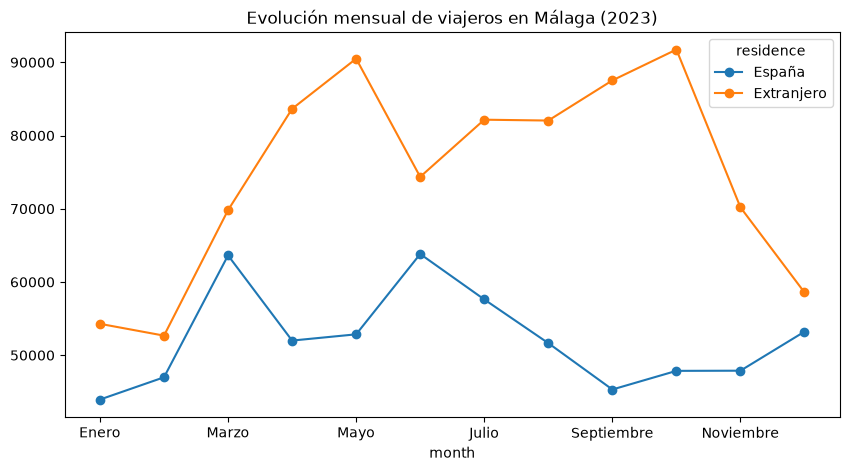

In [191]:
travelers_monthly.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Evolución mensual de viajeros en Málaga (2023)"
)

In [192]:
overnights_monthly = (
    tourism_df[tourism_df["indicator"] == "pernoctaciones"]
    .pivot(index="month", columns="residence", values="value")
    .reindex(month_order)
)

overnights_monthly

residence,España,Extranjero
month,,
Enero,81126.0,132244.0
Febrero,82768.0,132627.0
Marzo,108507.0,161186.0
Abril,99044.0,192804.0
Mayo,97313.0,201971.0
Junio,112889.0,173227.0
Julio,109269.0,205945.0
Agosto,118620.0,218849.0
Septiembre,86799.0,207089.0


<Axes: title={'center': 'Evolución mensual de pernoctaciones en Málaga (2023)'}, xlabel='month'>

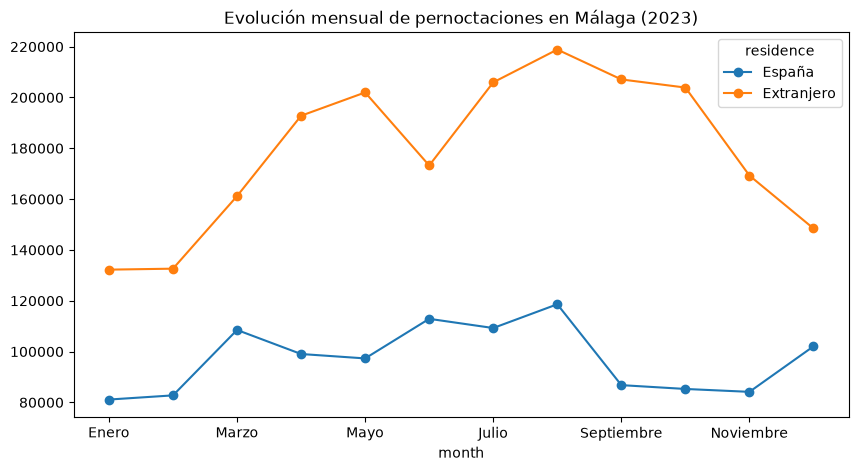

In [193]:
overnights_monthly.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Evolución mensual de pernoctaciones en Málaga (2023)"
)

## EDA - Percepción de los residentes por distrito

In [194]:
perception_df.describe().round(2)

,district,positive_pct,negative_pct,no_answer_pct
count,11.00,11.00,11.00,11.00
mean,6.00,76.10,12.42,11.48
std,3.32,7.28,10.73,7.74
min,1.00,60.53,0.00,0.00
25%,3.50,73.52,7.25,5.46
50%,6.00,75.91,11.87,9.22
75%,8.50,80.63,15.06,17.50
max,11.00,87.80,39.47,24.09


In [195]:
perception_df[
    ["district", "negative_pct"]
].sort_values(
    "negative_pct",
    ascending=False
)

,district,negative_pct
7,8,39.47
0,1,18.26
6,7,16.05
5,6,14.06
3,4,12.50
1,2,11.87
2,3,9.90
10,11,7.37
4,5,7.13
8,9,0.00


<Axes: title={'center': 'Percepción negativa del turismo por distrito (2023)'}, xlabel='district'>

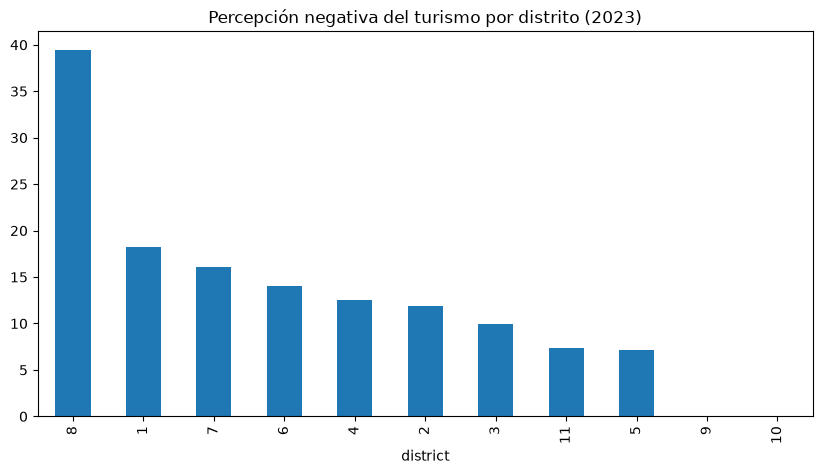

In [196]:
(
    perception_df
    .sort_values("negative_pct", ascending=False)
    .plot(
        x="district",
        y="negative_pct",
        kind="bar",
        figsize=(10, 5),
        title="Percepción negativa del turismo por distrito (2023)",
        legend=False
    )
)

## EDA - Viviendas de uso turístico (VUT) por distrito

In [197]:
vut_by_district.describe().round(2)

,NUMERO,vut_count
count,11.00,11.00
mean,6.00,908.27
std,3.32,1834.80
min,1.00,19.00
25%,3.50,60.50
50%,6.00,193.00
75%,8.50,796.00
max,11.00,6302.00


In [198]:
vut_by_district.sort_values(
    "vut_count",
    ascending=False
)

,NUMERO,NOMBRE,vut_count
0,1,CENTRO,6302
6,7,CARRETERA DE CADIZ,1191
1,2,ESTE,1058
5,6,CRUZ DE HUMILLADERO,534
3,4,BAILEN-MIRAFLORES,350
10,11,TEATINOS-UNIVERSIDAD,193
7,8,CHURRIANA,178
2,3,CIUDAD JARDIN,64
4,5,PALMA-PALMILLA,57
9,10,PUERTO DE LA TORRE,45


<Axes: title={'center': 'Viviendas de uso turístico por distrito de Málaga (hasta 2023)'}, xlabel='NOMBRE'>

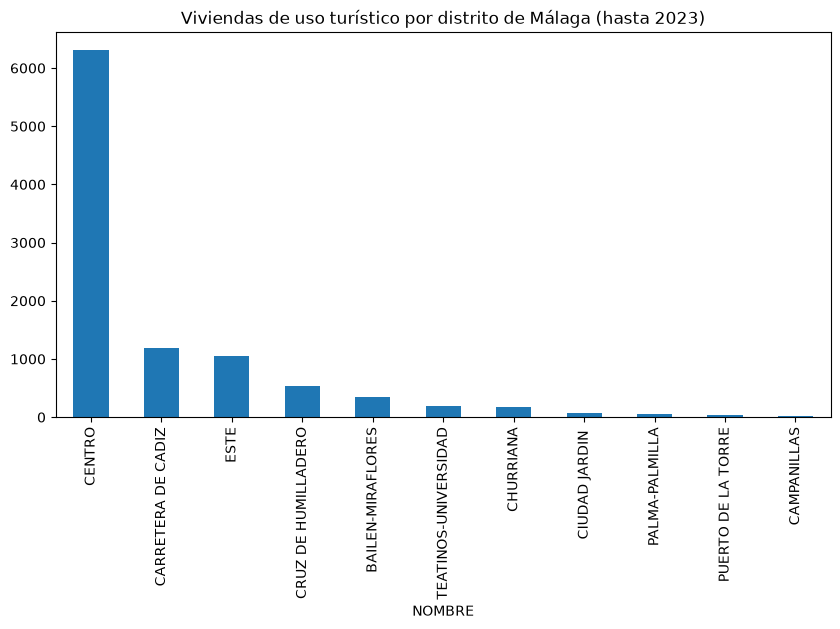

In [206]:
(
    vut_by_district
    .sort_values("vut_count", ascending=False)
    .plot(
        x="NOMBRE",
        y="vut_count",
        kind="bar",
        figsize=(10, 5),
        title="Viviendas de uso turístico por distrito de Málaga (hasta 2023)",
        legend=False
    )
)

# Análisis conjunto y visualizaciones finales

En esta sección se analiza la relación entre la concentración de viviendas de uso turístico (VUT) y la percepción negativa del turismo en los distritos de Málaga.

In [207]:
analysis_df = vut_by_district.merge(
    perception_df,
    left_on="NUMERO",
    right_on="district",
    how="inner"
)

analysis_df

,NUMERO,NOMBRE,vut_count,district,positive_pct,negative_pct,no_answer_pct
0,1,CENTRO,6302,1,73.88,18.26,7.86
1,2,ESTE,1058,2,78.91,11.87,9.22
2,3,CIUDAD JARDIN,64,3,73.16,9.90,16.94
3,4,BAILEN-MIRAFLORES,350,4,69.88,12.50,17.62
4,5,PALMA-PALMILLA,57,5,87.80,7.13,5.07
5,6,CRUZ DE HUMILLADERO,534,6,82.35,14.06,3.59
6,7,CARRETERA DE CADIZ,1191,7,78.10,16.05,5.85
7,8,CHURRIANA,178,8,60.53,39.47,0.00
8,9,CAMPANILLAS,19,9,82.62,0.00,17.38
9,10,PUERTO DE LA TORRE,45,10,75.91,0.00,24.09


In [208]:
correlation = analysis_df["vut_count"].corr(
    analysis_df["negative_pct"]
)

round(correlation, 3)

np.float64(0.224)

<Axes: title={'center': 'VUT y percepción negativa del turismo por distrito'}, xlabel='vut_count', ylabel='negative_pct'>

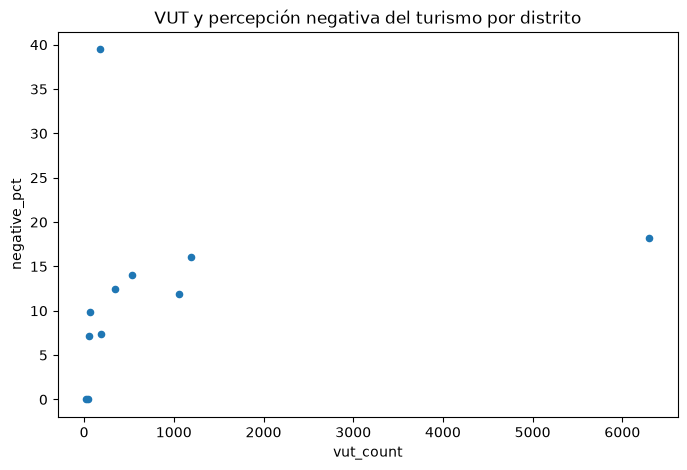

In [209]:
analysis_df.plot(
    x="vut_count",
    y="negative_pct",
    kind="scatter",
    figsize=(8, 5),
    title="VUT y percepción negativa del turismo por distrito"
)

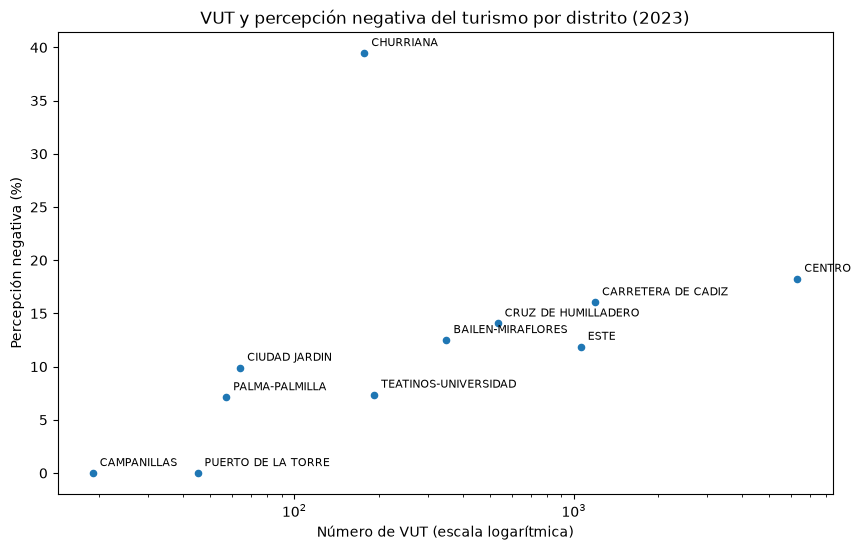

In [215]:
ax = analysis_df.plot(
    x="vut_count",
    y="negative_pct",
    kind="scatter",
    figsize=(10, 6),
    logx=True,
    title="VUT y percepción negativa del turismo por distrito (2023)"
)

ax.set_xlabel("Número de VUT (escala logarítmica)")
ax.set_ylabel("Percepción negativa (%)")

for _, row in analysis_df.iterrows():
    ax.annotate(
        row["NOMBRE"],
        (row["vut_count"], row["negative_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

### Relación entre VUT y percepción negativa

La correlación de Pearson entre el número de VUT y el porcentaje de percepción negativa es de **0,224**, lo que indica una relación positiva débil entre ambas variables.

Los resultados no muestran una relación lineal fuerte entre una mayor concentración de VUT y una percepción más negativa del turismo. Destaca el caso de **Churriana**, que presenta el mayor porcentaje de percepción negativa (39,47 %) pese a contar con muchas menos VUT que distritos como Centro, Carretera de Cádiz o Este.

Por tanto, los resultados sugieren que la concentración de VUT por sí sola no explica las diferencias en la percepción negativa entre los distritos. Este análisis es descriptivo y no permite establecer relaciones causales.

In [216]:
comparison_df = analysis_df[
    ["NOMBRE", "vut_count", "negative_pct"]
].sort_values(
    "vut_count",
    ascending=False
)

comparison_df

,NOMBRE,vut_count,negative_pct
0,CENTRO,6302,18.26
6,CARRETERA DE CADIZ,1191,16.05
1,ESTE,1058,11.87
5,CRUZ DE HUMILLADERO,534,14.06
3,BAILEN-MIRAFLORES,350,12.50
10,TEATINOS-UNIVERSIDAD,193,7.37
7,CHURRIANA,178,39.47
2,CIUDAD JARDIN,64,9.90
4,PALMA-PALMILLA,57,7.13
9,PUERTO DE LA TORRE,45,0.00


Text(0, 0.5, 'Percepción negativa (%)')

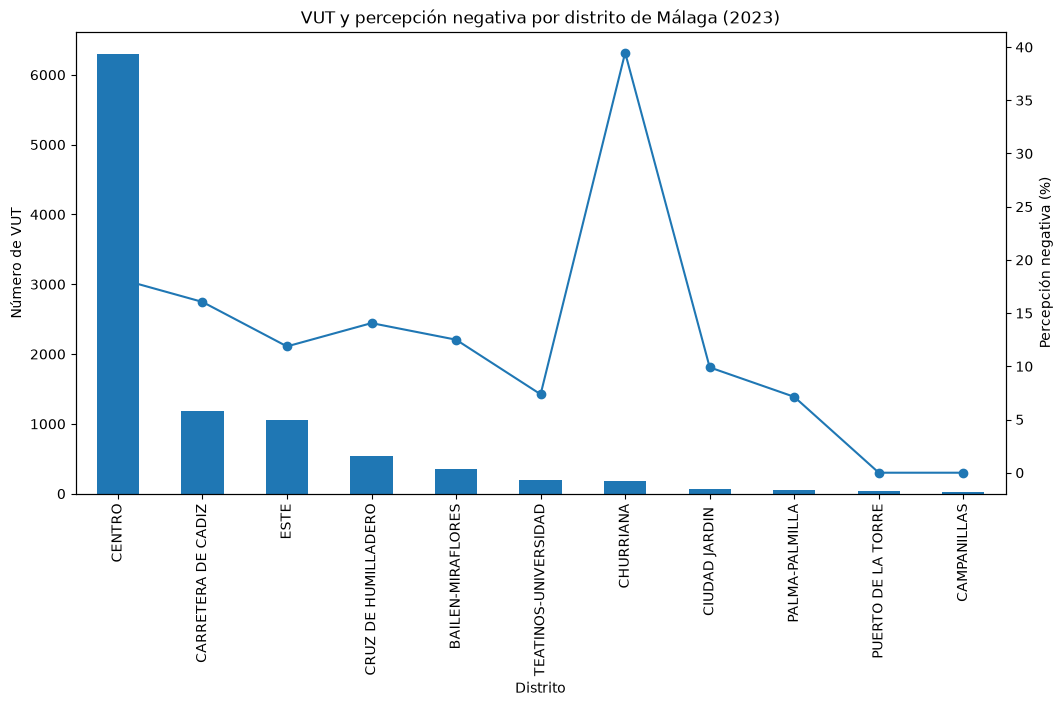

In [217]:
ax = comparison_df.plot(
    x="NOMBRE",
    y="vut_count",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

ax.set_ylabel("Número de VUT")
ax.set_xlabel("Distrito")
ax.set_title("VUT y percepción negativa por distrito de Málaga (2023)")

ax2 = ax.twinx()

ax2.plot(
    range(len(comparison_df)),
    comparison_df["negative_pct"],
    marker="o"
)

ax2.set_ylabel("Percepción negativa (%)")

In [218]:
map_df = districts_gdf.merge(
    analysis_df,
    left_on="NUMERO",
    right_on="district",
    how="left"
)

map_df[["NUMERO_x", "NOMBRE_x", "vut_count", "negative_pct"]]

,NUMERO_x,NOMBRE_x,vut_count,negative_pct
0,8,CHURRIANA,178,39.47
1,7,CARRETERA DE CADIZ,1191,16.05
2,11,TEATINOS-UNIVERSIDAD,193,7.37
3,6,CRUZ DE HUMILLADERO,534,14.06
4,4,BAILEN-MIRAFLORES,350,12.50
5,5,PALMA-PALMILLA,57,7.13
6,3,CIUDAD JARDIN,64,9.90
7,2,ESTE,1058,11.87
8,1,CENTRO,6302,18.26
9,10,PUERTO DE LA TORRE,45,0.00


<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

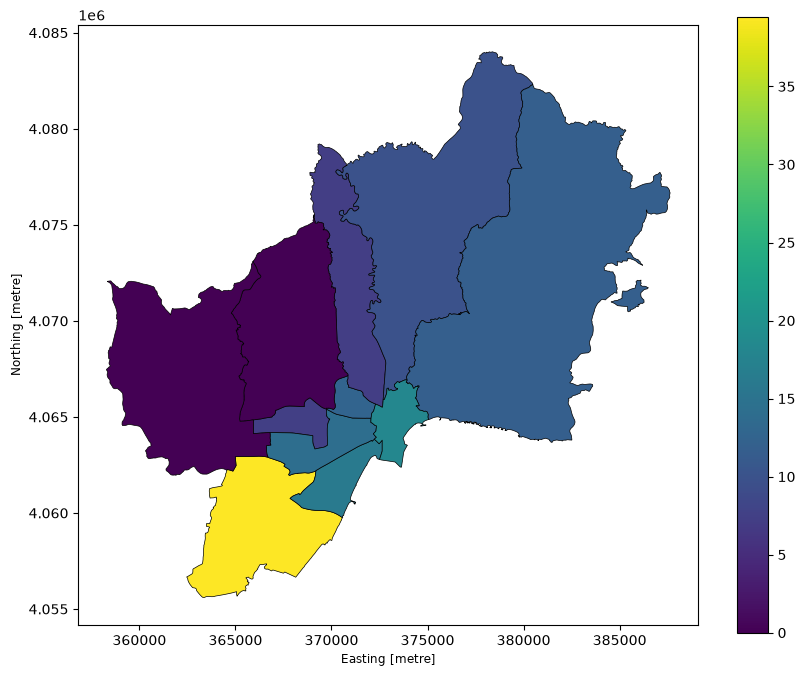

In [219]:
map_df.plot(
    column="negative_pct",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.5
)

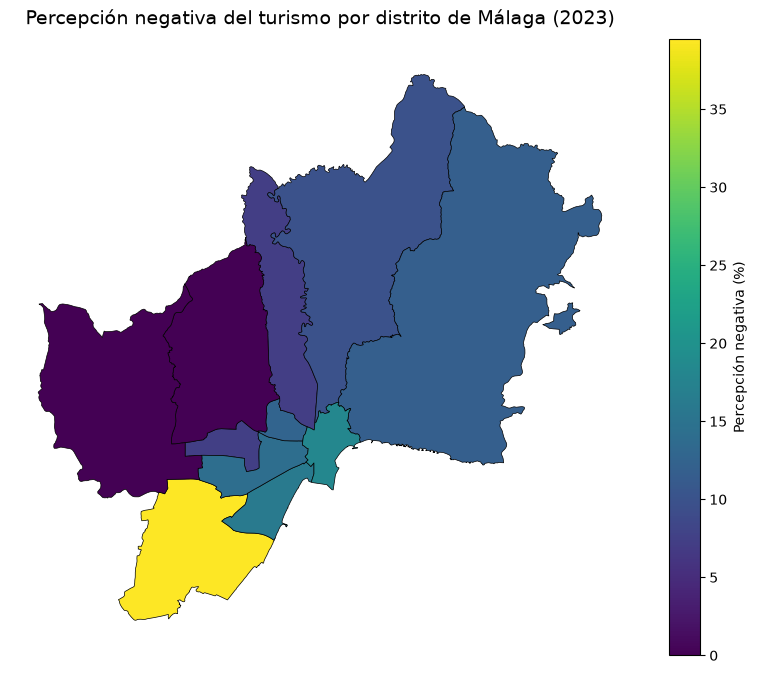

In [220]:
ax = map_df.plot(
    column="negative_pct",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"label": "Percepción negativa (%)"}
)

ax.set_title(
    "Percepción negativa del turismo por distrito de Málaga (2023)",
    fontsize=14
)

ax.set_axis_off()

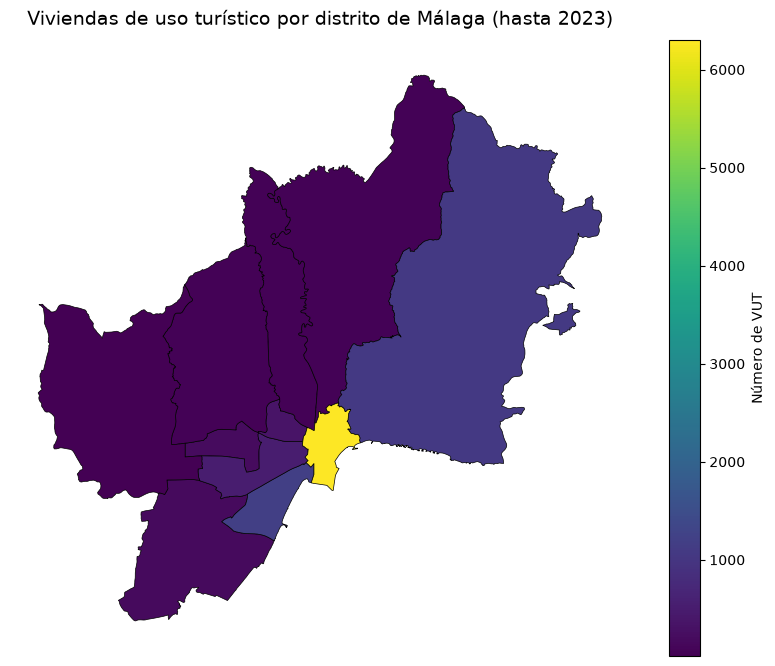

In [221]:
ax = map_df.plot(
    column="vut_count",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"label": "Número de VUT"}
)

ax.set_title(
    "Viviendas de uso turístico por distrito de Málaga (hasta 2023)",
    fontsize=14
)

ax.set_axis_off()

### Distribución territorial

Los mapas muestran diferencias entre la distribución territorial de las VUT y la percepción negativa del turismo.

La concentración de VUT destaca especialmente en el distrito Centro, mientras que la mayor percepción negativa se registra en Churriana. Por tanto, los distritos con mayor concentración absoluta de VUT no coinciden necesariamente con aquellos donde existe una mayor percepción negativa del turismo.

Este patrón es coherente con la correlación positiva débil obtenida entre ambas variables (r = 0,224) y sugiere que pueden existir otros factores relacionados con la percepción de los residentes.

## Limitaciones del análisis

- El análisis se realiza sobre los 11 distritos de Málaga, por lo que los resultados deben interpretarse de forma descriptiva y exploratoria.
- El número de VUT representa una concentración absoluta por distrito y no está normalizado por población, número de viviendas o superficie.
- Los datos de OpenRTA corresponden a establecimientos actualmente presentes en el registro cuya fecha de inscripción es igual o anterior al 31/12/2023, por lo que no representan necesariamente el stock histórico exacto de VUT existente en 2023.
- La correlación entre VUT y percepción negativa indica asociación, pero no permite establecer una relación causal.
- La percepción de los residentes puede estar relacionada con otros factores que no se incluyen en este análisis.

# Conclusiones

El análisis muestra que la distribución de las viviendas de uso turístico (VUT) en Málaga es muy desigual entre los distritos, con una fuerte concentración en Centro.

Sin embargo, los distritos con mayor número de VUT no presentan necesariamente una mayor percepción negativa del turismo. La correlación de Pearson entre el número absoluto de VUT y la percepción negativa es de **0,224**, lo que indica una asociación positiva débil.

Para comprobar si el diferente tamaño territorial de los distritos podía influir en el resultado, se calculó también la densidad de VUT por km². La correlación con la percepción negativa fue de **0,205**, manteniéndose igualmente como una asociación positiva débil.

Destaca especialmente Churriana, que presenta el mayor porcentaje de percepción negativa (**39,47 %**) pese a contar con 178 VUT y una densidad de solo **5,18 VUT/km²**.

Por tanto, la hipótesis inicial no queda claramente respaldada por los datos: ni una mayor concentración absoluta de VUT ni una mayor densidad de VUT por superficie muestran una relación lineal fuerte con una percepción más negativa del turismo entre los residentes.

Los resultados sugieren que la percepción del turismo puede estar relacionada con otros factores sociales, económicos o territoriales que no han sido analizados en este proyecto.

In [158]:
correlation = analysis_df[
    ["vut_count", "negative_pct"]
].corr()

correlation

,vut_count,negative_pct
vut_count,1.000000,0.223796
negative_pct,0.223796,1.000000


In [159]:
tourism_df.groupby(["indicator", "residence"])["value"].describe().round(2)

count       mean       std       min        25%  \
indicator      residence                                                     
pernoctaciones España       20.0   91091.35  14981.69   71852.0   78263.25   
               Extranjero   20.0  222299.80  43478.22  147969.0  186336.50   
viajeros       España       20.0   51134.65   6382.68   39661.0   46412.00   
               Extranjero   20.0   97634.95  18126.72   62480.0   85709.50   

                                50%        75%       max  
indicator      residence                                  
pernoctaciones España       91261.0   99267.75  125165.0  
               Extranjero  225850.0  244683.00  313458.0  
viajeros       España       52425.0   55443.25   60646.0  
               Extranjero  105937.0  110862.75  119163.0

In [160]:
print("Fecha inicial:", tourism_df["date"].min())
print("Fecha final:", tourism_df["date"].max())
print("Años disponibles:", sorted(tourism_df["year"].unique()))

Fecha inicial: 2025-01-01 00:00:00
Fecha final: 2026-08-01 00:00:00
Años disponibles: [np.int64(2025), np.int64(2026)]


In [ ]:
# calcular superficie por distrito

districts_gdf["area_km2"] = districts_gdf.geometry.area / 1_000_000

districts_gdf[["NUMERO", "NOMBRE", "area_km2"]].round(2)

,NUMERO,NOMBRE,area_km2
0,8,CHURRIANA,34.35
1,7,CARRETERA DE CADIZ,8.09
2,11,TEATINOS-UNIVERSIDAD,5.42
3,6,CRUZ DE HUMILLADERO,9.37
4,4,BAILEN-MIRAFLORES,3.06
5,5,PALMA-PALMILLA,25.45
6,3,CIUDAD JARDIN,76.26
7,2,ESTE,127.60
8,1,CENTRO,7.16
9,10,PUERTO DE LA TORRE,42.46


In [ ]:
# calcular VUT por km²

vut_density_df = vut_by_district.merge(
    districts_gdf[["NUMERO", "area_km2"]],
    on="NUMERO",
    how="left"
)

vut_density_df["vut_per_km2"] = (
    vut_density_df["vut_count"] / vut_density_df["area_km2"]
)

vut_density_df[
    ["NUMERO", "NOMBRE", "vut_count", "area_km2", "vut_per_km2"]
].round(2)

,NUMERO,NOMBRE,vut_count,area_km2,vut_per_km2
0,1,CENTRO,6302,7.16,880.55
1,2,ESTE,1058,127.60,8.29
2,3,CIUDAD JARDIN,64,76.26,0.84
3,4,BAILEN-MIRAFLORES,350,3.06,114.30
4,5,PALMA-PALMILLA,57,25.45,2.24
5,6,CRUZ DE HUMILLADERO,534,9.37,56.97
6,7,CARRETERA DE CADIZ,1191,8.09,147.25
7,8,CHURRIANA,178,34.35,5.18
8,9,CAMPANILLAS,19,58.49,0.32
9,10,PUERTO DE LA TORRE,45,42.46,1.06


In [225]:
# calcular VUT por km²
density_analysis_df = vut_density_df.merge(
    perception_df,
    left_on="NUMERO",
    right_on="district",
    how="inner"
)

density_correlation = density_analysis_df["vut_per_km2"].corr(
    density_analysis_df["negative_pct"]
)

round(density_correlation, 3)

np.float64(0.205)

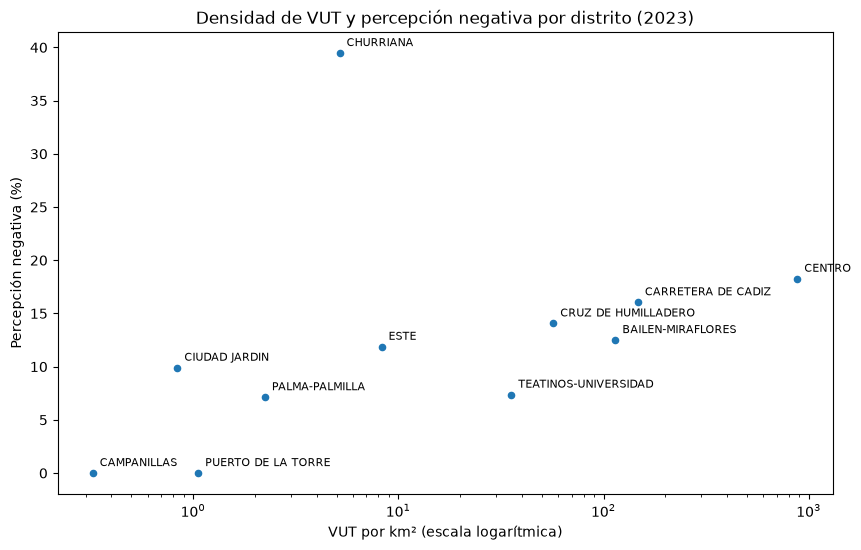

In [ ]:

ax = density_analysis_df.plot(
    x="vut_per_km2",
    y="negative_pct",
    kind="scatter",
    figsize=(10, 6),
    logx=True,
    title="Densidad de VUT y percepción negativa por distrito (2023)"
)

ax.set_xlabel("VUT por km² (escala logarítmica)")
ax.set_ylabel("Percepción negativa (%)")

for _, row in density_analysis_df.iterrows():
    ax.annotate(
        row["NOMBRE"],
        (row["vut_per_km2"], row["negative_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

### Densidad de VUT y percepción negativa

Para complementar el análisis basado en el número absoluto de viviendas de uso turístico, se calculó la densidad de VUT por km² en cada distrito.

La correlación de Pearson entre la densidad de VUT y la percepción negativa es de **0,205**, lo que indica nuevamente una asociación positiva débil. Este resultado es similar al obtenido utilizando el número absoluto de VUT (**r = 0,224**).

Aunque Centro presenta una densidad de VUT muy superior al resto de distritos, Churriana registra la mayor percepción negativa pese a tener una densidad relativamente baja.

Por tanto, ajustar la concentración de VUT por la superficie del distrito no modifica sustancialmente la conclusión inicial: la presencia de VUT, por sí sola, no parece explicar las diferencias en la percepción negativa del turismo entre los distritos de Málaga.